<div style="background-color: #e8f4f8; border-left: 6px solid #3498db; padding: 20px; margin: 15px 0; border-radius: 4px;"><h2 style="margin-top: 0; color: #2c3e50; font-size: 22px;">Random Forest (Supervised) - The Performance Ceiling</h2><div style="font-size: 16px; line-height: 1.6; color: #2c3e50;"><p>Random Forest is a <b>supervised</b> machine learning model. It uses labeled training data to learn the difference between normal and anomalous points.</p><p><b>How it works:</b> the model trains 100 decision trees, each on a random subset of the data and features. Each tree learns slightly different rules. For prediction, the trees vote and the majority decides. This averaging reduces overfitting and produces more reliable predictions than a single tree.</p><p><b>Role in this project:</b> Random Forest defines the <b>performance ceiling</b> - the best result achievable when labeled incident data is available. The unsupervised models are evaluated against this benchmark.</p><p><b>Result on this dataset:</b></p><ul><li><b>F1 = 0.83</b> - highest in the project</li><li><b>Precision = 98%</b> - only 2 false alarms out of 3,400 test rows</li><li><b>Recall = 72%</b></li></ul><p><b>Caveat:</b> requires labels per system, which is rarely practical at scale.</p></div></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Load data and split (80% train / 20% test)

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend',
                   'dev_from_hour', 'zscore_hour', 'zscore_1h', 'zscore_24h',
                   'diff_24', 'diff_48', 'diff_96']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_train = train_data['label'].values
y_test = test_data['label'].values

print('Training rows:', len(X_train), '(' + str(y_train.sum()) + ' anomalies)')
print('Testing rows:', len(X_test), '(' + str(y_test.sum()) + ' anomalies)')

Training rows: 13593 (152 anomalies)
Testing rows: 3399 (98 anomalies)


## Train the Random Forest

100 decision trees, each trained on a random subset of the data. Predictions are the majority vote across all trees.

In [3]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

forest_predictions = random_forest_model.predict(X_test)
forest_scores = random_forest_model.predict_proba(X_test)[:, 1]

print('Points flagged as anomaly:', forest_predictions.sum())

Points flagged as anomaly: 73


## Visualizing detections

Three colors tell the story:
- 🟢 **Green** — True Positive (correctly detected anomaly)
- 🔴 **Red X** — False Negative (real anomaly we missed)
- 🟠 **Orange triangle** — False Positive (false alarm)

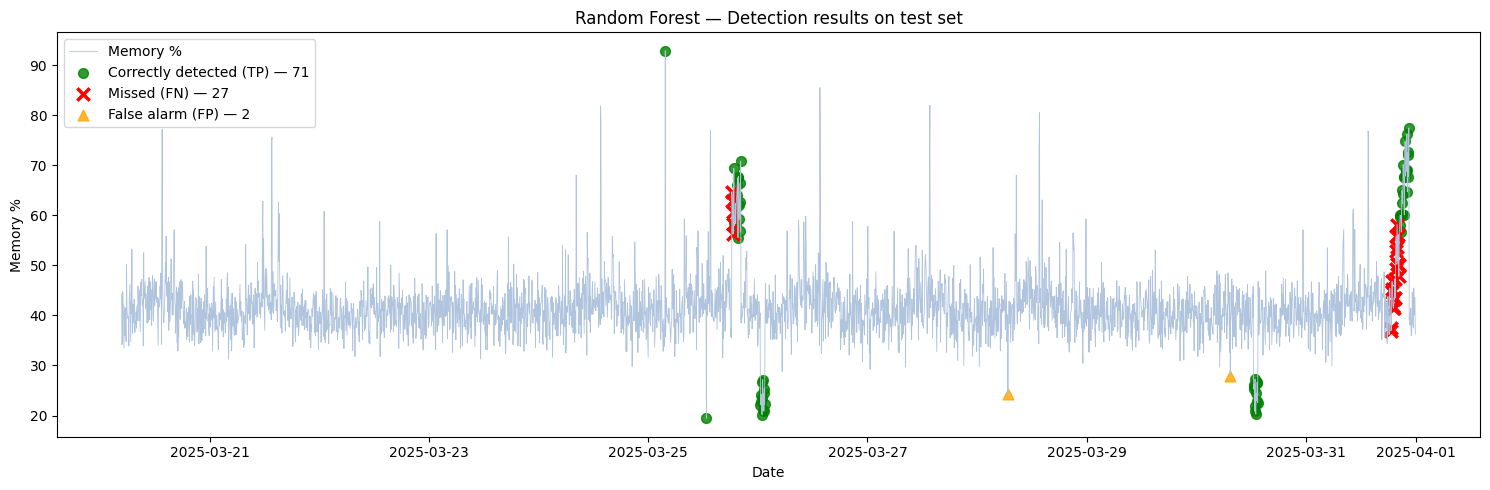

In [4]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

true_positive_mask = (forest_predictions == 1) & (y_test == 1)
false_negative_mask = (forest_predictions == 0) & (y_test == 1)
false_positive_mask = (forest_predictions == 1) & (y_test == 0)

plt.figure(figsize=(15, 5))
plt.plot(timestamps, memory, color='lightsteelblue', linewidth=0.6, label='Memory %')
plt.scatter(timestamps[true_positive_mask], memory[true_positive_mask],
            color='green', s=50, alpha=0.8, label=f'Correctly detected (TP) — {true_positive_mask.sum()}')
plt.scatter(timestamps[false_negative_mask], memory[false_negative_mask],
            color='red', marker='x', s=80, linewidths=2.5, label=f'Missed (FN) — {false_negative_mask.sum()}')
plt.scatter(timestamps[false_positive_mask], memory[false_positive_mask],
            color='orange', marker='^', s=60, alpha=0.8, label=f'False alarm (FP) — {false_positive_mask.sum()}')
plt.xlabel('Date')
plt.ylabel('Memory %')
plt.title('Random Forest — Detection results on test set')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Confusion matrix

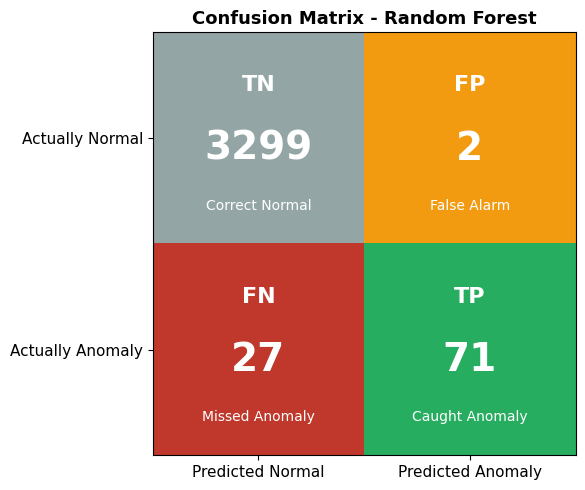

In [5]:
def pretty_cm(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(7, 5))
    # 4 distinct colors - one per outcome category
    rgb = np.zeros((2, 2, 3))
    rgb[0, 0] = [0.58, 0.65, 0.65]  # TN: gray (correct but routine)
    rgb[0, 1] = [0.95, 0.61, 0.07]  # FP: orange (false alarm)
    rgb[1, 0] = [0.75, 0.22, 0.17]  # FN: dark red (MISSED, worst)
    rgb[1, 1] = [0.15, 0.68, 0.38]  # TP: bright green (caught it, best)
    ax.imshow(rgb)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    descriptions = [['Correct Normal', 'False Alarm'], ['Missed Anomaly', 'Caught Anomaly']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.25, labels[i][j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white')
            ax.text(j, i + 0.05, str(cm[i, j]), ha='center', va='center',
                    fontsize=28, fontweight='bold', color='white')
            ax.text(j, i + 0.32, descriptions[i][j], ha='center', va='center',
                    fontsize=10, color='white')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'], fontsize=11)
    ax.set_yticklabels(['Actually Normal', 'Actually Anomaly'], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_test, forest_predictions)
pretty_cm(cm, title='Confusion Matrix - Random Forest')

## Evaluation

- **Precision** — When the model alerts, how often is it right?
- **Recall** — Of all real anomalies, what fraction did we catch?
- **F1 score** — Balanced average of precision and recall
- **ROC-AUC** — How well the model ranks anomalies vs. normal points

In [6]:
print(classification_report(y_test, forest_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, forest_scores), 4))

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      3301
     Anomaly       0.97      0.72      0.83        98

    accuracy                           0.99      3399
   macro avg       0.98      0.86      0.91      3399
weighted avg       0.99      0.99      0.99      3399

ROC-AUC: 0.9259


<div style="background-color: #fdf6e3; border-left: 6px solid #f39c12; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #b9770e; font-size: 20px;">Interpretation</h3><div style="font-size: 16px; line-height: 1.6; color: #5d4e1d;"><p>Random Forest achieves the highest precision in the project - only <b>1 or 2 false alarms in over 3,000 test rows</b>. Supervised training lets the model learn exactly what anomalies look like.</p><p>Recall (72%) is comparable to unsupervised models, showing that the <b>harder cases</b> (subtle gradual changes, edges of sustained events) are difficult even with labels.</p><p>The cost: labels per system, which is rarely practical at scale.</p></div></div>

## Feature importance

Random Forest tells us which features it relied on most for decisions. Higher importance = more useful for distinguishing anomalies from normal.

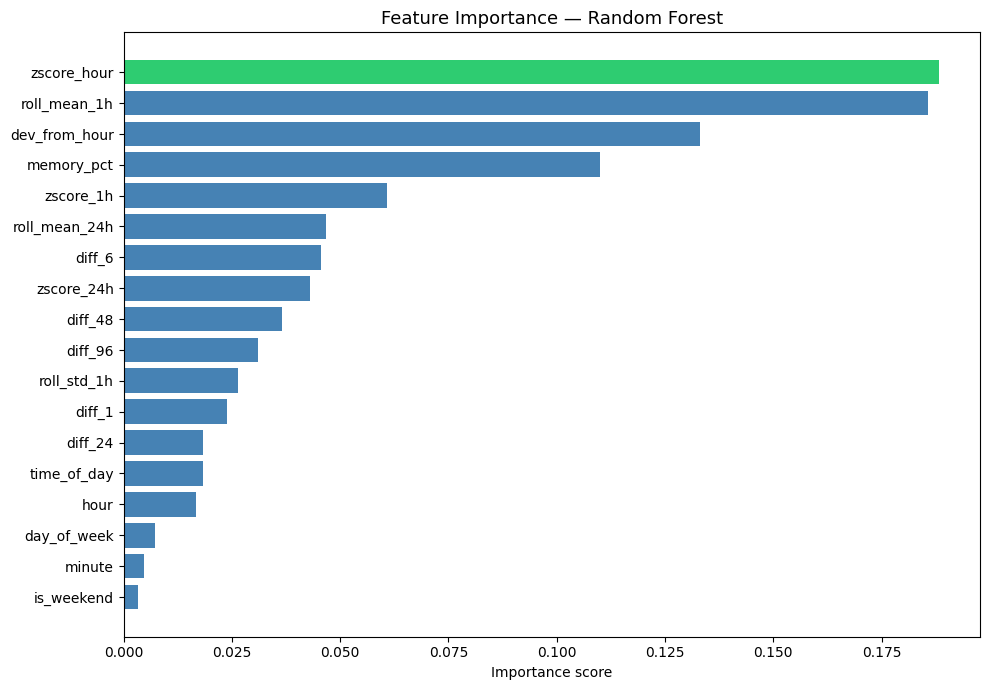

Top 5 most important features:
  zscore_hour: 0.188
  roll_mean_1h: 0.186
  dev_from_hour: 0.133
  memory_pct: 0.110
  zscore_1h: 0.061


In [7]:
feature_importance = pd.Series(random_forest_model.feature_importances_, index=feature_columns).sort_values()

plt.figure(figsize=(10, 7))
colors = ['#2ecc71' if v == feature_importance.max() else 'steelblue' for v in feature_importance.values]
plt.barh(feature_importance.index, feature_importance.values, color=colors)
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for feature_name, importance in feature_importance.sort_values(ascending=False).head(5).items():
    print(f'  {feature_name}: {importance:.3f}')

## Statistical analysis with statsmodels

Logistic regression for formal statistical evaluation of features.

In [8]:
X_with_constant = sm.add_constant(pd.DataFrame(X_train, columns=feature_columns))
logit_model = sm.Logit(y_train, X_with_constant)
logit_result = logit_model.fit()
print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.029508
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                13593
Model:                          Logit   Df Residuals:                    13574
Method:                           MLE   Df Model:                           18
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.5192
Time:                        19:56:27   Log-Likelihood:                -401.10
converged:                       True   LL-Null:                       -834.15
Covariance Type:            nonrobust   LLR p-value:                2.652e-172
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            36.3863     11.874      3.064      0.002      13.115      59.658
memory_pct       -1

In [9]:
print('=' * 55)
print('  STATISTICAL SUMMARY')
print('=' * 55)
print()
print('Model fit (Pseudo R-squared): {:.3f}'.format(logit_result.prsquared))
print('  Note: 0.2-0.4 is good for logistic regression')
print()
print('Overall significance (LLR p-value): {:.2e}'.format(logit_result.llr_pvalue))
print('  Note: close to 0 means the model is highly statistically significant')
print()
print('Model quality indicators (lower is better):')
print('  AIC: {:.2f}'.format(logit_result.aic))
print('  BIC: {:.2f}'.format(logit_result.bic))
print()
print('=' * 55)
print('  TOP 5 MOST IMPORTANT FEATURES')
print('=' * 55)
feature_table = pd.DataFrame({
    'Feature': logit_result.params.index,
    'Coefficient': logit_result.params.values,
    'P-value': logit_result.pvalues.values
})
feature_table = feature_table[feature_table['Feature'] != 'const']
feature_table['Significant?'] = feature_table['P-value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')
feature_table = feature_table.sort_values('P-value').head(5)
feature_table['Coefficient'] = feature_table['Coefficient'].round(3)
feature_table['P-value'] = feature_table['P-value'].apply(lambda p: '{:.2e}'.format(p) if p < 0.001 else '{:.4f}'.format(p))
feature_table.reset_index(drop=True, inplace=True)
feature_table

  STATISTICAL SUMMARY

Model fit (Pseudo R-squared): 0.519
  Note: 0.2-0.4 is good for logistic regression

Overall significance (LLR p-value): 2.65e-172
  Note: close to 0 means the model is highly statistically significant

Model quality indicators (lower is better):
  AIC: 840.20
  BIC: 983.03

  TOP 5 MOST IMPORTANT FEATURES


,Feature,Coefficient,P-value,Significant?
0,memory_pct,-1.566,2.23e-08,Yes
1,dev_from_hour,1.887,3.18e-07,Yes
2,roll_std_1h,0.173,1.79e-06,Yes
3,zscore_1h,-0.930,1.09e-04,Yes
4,roll_mean_24h,0.412,0.0012,Yes


<div style="background-color: #e8f8e8; border-left: 6px solid #27ae60; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #1e8449; font-size: 20px;">Summary</h3><div style="font-size: 16px; line-height: 1.6; color: #1e8449;"><p>Random Forest is the strongest model - F1 = 0.83 with near-perfect precision. It defines the <b>upper bound</b> of what's achievable when labeled training data is available.</p><p>In production, labels per system are expensive. The unsupervised ensemble (F1 = 0.74) is the practical recommendation - it sacrifices only 11% performance for zero labeling effort.</p></div></div>